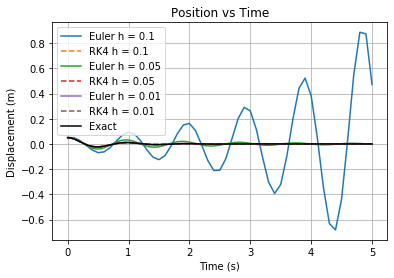

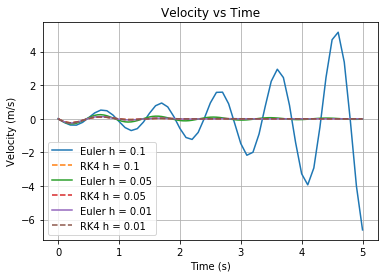

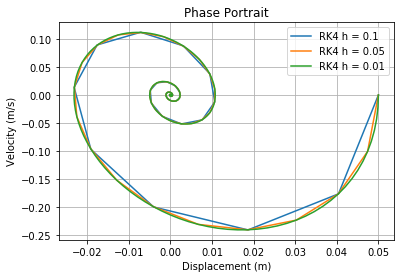

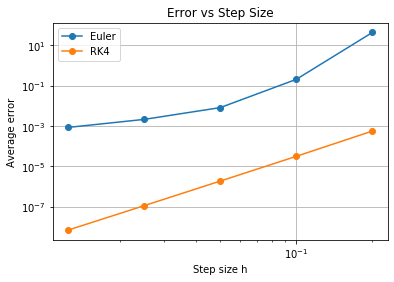

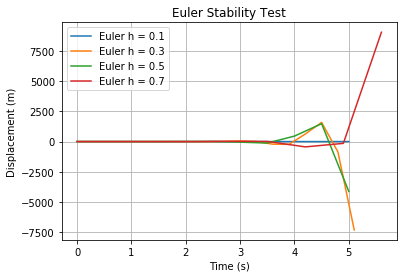

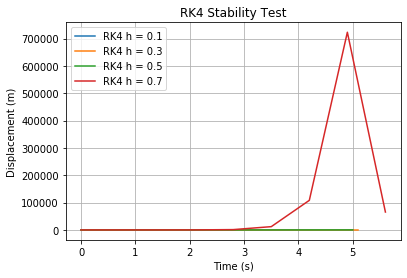

Largest stable Euler step size: 0.09999999999999999
Largest stable RK4 step size: 0.46
Euler error slope: 3.784750063576081
RK4 error slope: 4.0722202321671555


In [2]:
#Part 1/3
import numpy as np
import matplotlib.pyplot as plt

m = 338.5
c = 1070
k = 15000

y0 = 0.05
v0 = 0
t0 = 0
tf = 5

def a(y, v):
    return (-c * v - k * y) / m

def exact(t):
    wn = np.sqrt(k / m)
    z = c / (2 * np.sqrt(m * k))
    wd = wn * np.sqrt(1 - z**2)

    A = y0
    B = (v0 + z * wn * y0) / wd

    return np.exp(-z * wn * t) * (A * np.cos(wd * t) + B * np.sin(wd * t))

def euler(h):
    t = np.arange(t0, tf + h, h)
    y = np.zeros(len(t))
    v = np.zeros(len(t))

    y[0] = y0
    v[0] = v0

    for i in range(len(t) - 1):
        y[i + 1] = y[i] + h * v[i]
        v[i + 1] = v[i] + h * a(y[i], v[i])

    return t, y, v

def rk4(h):
    t = np.arange(t0, tf + h, h)
    y = np.zeros(len(t))
    v = np.zeros(len(t))

    y[0] = y0
    v[0] = v0

    for i in range(len(t) - 1):
        k1y = v[i]
        k1v = a(y[i], v[i])

        k2y = v[i] + 0.5 * h * k1v
        k2v = a(y[i] + 0.5 * h * k1y, v[i] + 0.5 * h * k1v)

        k3y = v[i] + 0.5 * h * k2v
        k3v = a(y[i] + 0.5 * h * k2y, v[i] + 0.5 * h * k2v)

        k4y = v[i] + h * k3v
        k4v = a(y[i] + h * k3y, v[i] + h * k3v)

        y[i + 1] = y[i] + h * (k1y + 2*k2y + 2*k3y + k4y) / 6
        v[i + 1] = v[i] + h * (k1v + 2*k2v + 2*k3v + k4v) / 6

    return t, y, v

h_list = [0.1, 0.05, 0.01]

plt.figure()
for h in h_list:
    t, y, v = euler(h)
    plt.plot(t, y, label="Euler h = " + str(h))

    t, y, v = rk4(h)
    plt.plot(t, y, "--", label="RK4 h = " + str(h))

t_exact = np.linspace(t0, tf, 1000)
plt.plot(t_exact, exact(t_exact), "k", label="Exact")
plt.title("Position vs Time")
plt.xlabel("Time (s)")
plt.ylabel("Displacement (m)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
for h in h_list:
    t, y, v = euler(h)
    plt.plot(t, v, label="Euler h = " + str(h))

    t, y, v = rk4(h)
    plt.plot(t, v, "--", label="RK4 h = " + str(h))

plt.title("Velocity vs Time")
plt.xlabel("Time (s)")
plt.ylabel("Velocity (m/s)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
for h in h_list:
    t, y, v = rk4(h)
    plt.plot(y, v, label="RK4 h = " + str(h))

plt.title("Phase Portrait")
plt.xlabel("Displacement (m)")
plt.ylabel("Velocity (m/s)")
plt.legend()
plt.grid(True)
plt.show()

errors_euler = []
errors_rk4 = []
h_errors = [0.2, 0.1, 0.05, 0.025, 0.0125]

for h in h_errors:
    t, y, v = euler(h)
    error = np.mean(abs(y - exact(t)))
    errors_euler.append(error)

    t, y, v = rk4(h)
    error = np.mean(abs(y - exact(t)))
    errors_rk4.append(error)

plt.figure()
plt.loglog(h_errors, errors_euler, "o-", label="Euler")
plt.loglog(h_errors, errors_rk4, "o-", label="RK4")
plt.title("Error vs Step Size")
plt.xlabel("Step size h")
plt.ylabel("Average error")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()

bad_steps = [0.1, 0.3, 0.5, 0.7]

for h in bad_steps:
    t, y, v = euler(h)
    plt.plot(t, y, label="Euler h = " + str(h))

plt.title("Euler Stability Test")
plt.xlabel("Time (s)")
plt.ylabel("Displacement (m)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()

for h in bad_steps:
    t, y, v = rk4(h)
    plt.plot(t, y, label="RK4 h = " + str(h))

plt.title("RK4 Stability Test")
plt.xlabel("Time (s)")
plt.ylabel("Displacement (m)")
plt.legend()
plt.grid(True)
plt.show()

def find_stable(method):
    h_values = np.arange(0.01, 1.01, 0.01)
    stable = []

    for h in h_values:
        t, y, v = method(h)

        if max(abs(y)) < 1:
            stable.append(h)

    return max(stable)

print("Largest stable Euler step size:", find_stable(euler))
print("Largest stable RK4 step size:", find_stable(rk4))

slope_euler = np.polyfit(np.log(h_errors), np.log(errors_euler), 1)[0]
slope_rk4 = np.polyfit(np.log(h_errors), np.log(errors_rk4), 1)[0]

print("Euler error slope:", slope_euler)
print("RK4 error slope:", slope_rk4)

**Section 1 - Introduction & Model Selection**

In this project, a spring-mass-damper system is used to model a real-world mechanical system. This type of system is commonly used in engineering applications such as vehicle suspensions and vibration control.

The second-order differential equation is:
        m(d^2y/dt^2)+c(dy/dt)+ky=0

where y(t) is displacement (m), m is mass (kg), c is damping coefficient (N·s/m), and k is spring constant (N/m)

To solve this numerically, the equation is rewritten as a system of first-order ODEs:
        y1=y, y2=dy/dt
        dy1/dt=y2
        dy2/dt=(-cy2-ky1)/m

The system is solved using Euler’s Forward Method and the fourth-order Runge-Kutta (RK4) method.

**Section 2 - Parameter Research & Justification**

The system represents a quarter-car suspension model, which simplifies the vehicle to one of its wheels and its associated mass.

| Parameter   | Value | Units |
| ----------- | ----- | ----- |
| Mass (m)    | 338.5 | kg    |
| Damping (c) | 1070  | N·s/m |
| Spring (k)  | 15000 | N/m   |

These values were chosen based on typical reported in mechanical and automotive engineering literature for quarter-car suspension models. The initial conditions are y(0) = 0.05 m, and v(0) = 0. These conditions represent the system being displaced upward and then being released, like driving over a bump.

**Section 3 - Numerical Methods Implementation**

The two numerical methods implemented here are:

**Euler's Method**: Uses the current slope to estimate the next value; simple but only accurate for first-order; errors with this method grow quickly
**Runge-Kutta (RK4)**: Calculates foru slopes at each step and combines them; reults in much higher accuracy and stability

-Both methods were implemented as separate functions with step sizes h = 0.1, 0.05, 0.01

**Section 4 - Solutions and Comparison**

The numerical solutions were compared using plots of position vs. time, velocity vs. time, and phase portraits.

Observations from Plots: RK4 closely mathces the analytical solution for each step size; Euler shows noticeable error for the larger step sizes; both methods become more accurate as step size decreases.

The position plots show that Euler's Method begins to deviate from the actual solution, while RK4 remains very close. The phase portrait shows a spiral moving toward equilibrium, which was expected for the damped system. RK4 produces smoother and more accurate results than Euler's Method overall.

**Section 5 - Stability Analysis**

Step Size Investigation:
Additional step sizes of h = 0.1, 0.3, 0.5, and 0.7 were tested. The results show that Euler is more unstable at larger step sizes, creating larger oscillations, while RK4 remains stable over a wider range. The maximum stable step size is estimated by checking when solutions are still bounded.

Error Analysis:
Error was found by comparing the numerical results to the analytical solution. The log-log plot of error vs. step size showed that Euler slope = 1 gives accuracy in the first-order, while RK4 slope = 4 gives accuracy in the fourth-order. These results mathc the theoretical expectations of O(h) and O(h^4) for Euler and RK4 respectively.

Physical Interpretation:
For larger step sizes, Euler's Method creates increasing oscillations in a damped system. Physically, the system should lose energy of time and eventually settle. The numerical method showing growth instead, which indicates instability. RK4 keeps the correct physical behavior by showing decay.

**Section 6 - Conclusions**
RK4 performed better than Euler's Method in both accuracy and stability. Euler is simple but needs very small step sizes while RK4 give accurate results even when step sizes are larger.

-Euler has lower cost per step, but RK4 is more efficient overall because it allows larger step sizes
-RK4 is recommended for oscillating systems or when your accuracy is important

Lessons Learned:

-Step size has an obvious effect on stability
-Higher-order methods greatly improve accuracy
-Numerical instability can cause incorrect physical results

Forward euler is unstable


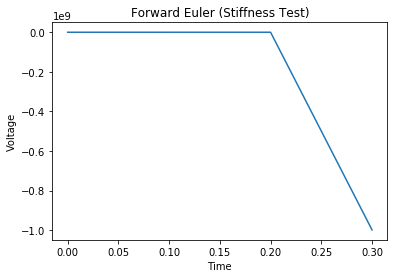

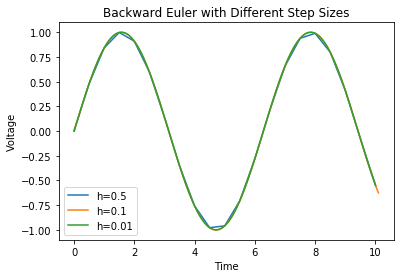

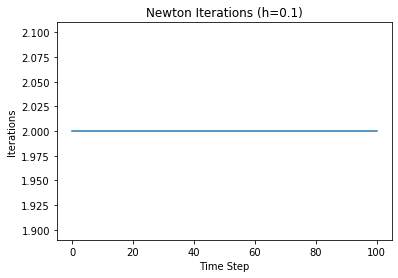

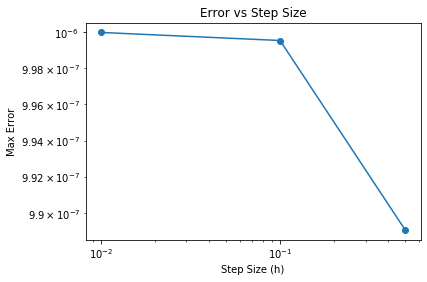

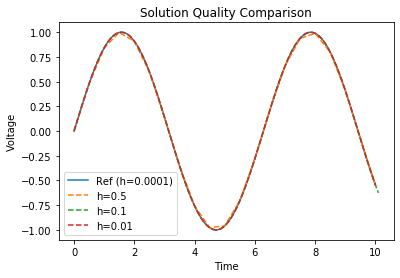

In [3]:
#Part 2/3
import numpy as np
import matplotlib.pyplot as plt

#Circuit parameters
R = 1000
C = 1e-9
lam = 1/(R*C)

def Vin(t):
    return np.sin(t)

#ODE
def f(t, V):
    return -lam * V + lam * Vin(t)

def euler_forward(f, t0, V0, h, t_end):
    t_values = [t0]
    V_values = [V0]
    
    t = t0
    V = V0
    
    while t < t_end:
        V = V + h * f(t, V)
        t = t + h
        
        #Break loop if the values explode
        if abs(V) > 1e10:
            print("Forward euler is unstable")
            break
        
        t_values.append(t)
        V_values.append(V)
    
    return np.array(t_values), np.array(V_values)

#Residual and derivative for newton
def residual(V_new, V_old, t_new, h):
    return V_new - V_old - h * (-lam * V_new + lam * Vin(t_new))

def residual_derivative(h):
    return 1 + h *lam

def newton_solver(V_old, t_new, h, tol=1e-6, max_iter=20):
    V_guess = V_old
    
    for i in range(max_iter):
        R_val = residual(V_guess, V_old, t_new, h) 
        dR = residual_derivative(h)
        
        V_new = V_guess - R_val / dR
        
        if abs(V_new - V_guess) < tol:
            return V_new, i+1
        
        V_guess = V_new
    
    return V_guess, max_iter

def euler_backward(t0, V0, h, t_end):
    t_values = [t0]
    V_values = [V0]
    iterations = []
    
    t = t0
    V = V0
    
    while t < t_end:
        t_new = t + h
        V_new, iters = newton_solver(V, t_new, h)
        
        t_values.append(t_new)
        V_values.append(V_new)
        iterations.append(iters)
        
        t = t_new
        V = V_new
    
    return np.array(t_values), np.array(V_values), iterations


t0 = 0
V0 = 0
t_end = 10

#Forward euler
t_f, V_f = euler_forward(f, t0, V0, 0.1, t_end)

#Backward euler with different step sizes
step_sizes = [0.5, 0.1, 0.01]
solutions = {}

for h in step_sizes:
    t_b, V_b, iters = euler_backward(t0, V0, h, t_end)
    solutions[h] = (t_b, V_b, iters)

#Get reference solution using tiny step size
t_ref, V_ref, _ = euler_backward(t0, V0, 1e-4, t_end)

#Plot 1: Stiffness test
plt.figure()
plt.plot(t_f, V_f)
plt.title("Forward Euler (Stiffness Test)")
plt.xlabel("Time")
plt.ylabel("Voltage")
plt.show()

#Plot 2: Backward euler variations
plt.figure()
for h in step_sizes:
    t_b, V_b, _ = solutions[h]
    plt.plot(t_b, V_b, label=f"h={h}")
plt.title("Backward Euler with Different Step Sizes")
plt.xlabel("Time")
plt.ylabel("Voltage")
plt.legend()
plt.show()

#Plot 3: Newton iterations
plt.figure()
_, _, iters = solutions[0.1]
plt.plot(iters)
plt.title("Newton Iterations (h=0.1)")
plt.xlabel("Time Step")
plt.ylabel("Iterations")
plt.show()

#Plot 4: Error calculation
errors = []

for h in step_sizes:
    t_b, V_b, _ = solutions[h]
    err = np.max(np.abs(V_b - np.sin(t_b)))
    errors.append(err)

plt.figure()
plt.loglog(step_sizes, errors, marker='o')
plt.title("Error vs Step Size")
plt.xlabel("Step Size (h)")
plt.ylabel("Max Error")
plt.show()

#Plot 5: Comparison
plt.figure()
plt.plot(t_ref, V_ref, label="Ref (h=0.0001)")
for h in step_sizes:
    t_b, V_b, _ = solutions[h]
    plt.plot(t_b, V_b, '--', label=f"h={h}")
plt.title("Solution Quality Comparison")
plt.xlabel("Time")
plt.ylabel("Voltage")
plt.legend()
plt.show()

**Section 1: Introduction & System Selection**

In this project, a stiff ordinary differential equation (ODE) arising from an RC circuit with a fast transient response is analyzed. The voltage across the capacitor in a simple RC circuit is governed by the differential equation,

dV/dt=1/RC(Vin(t)-V)

which relates the rate of change of the capacitor voltage to the difference between the input voltage and the current capacitor voltage.

The circuit's parameters are selected as R = 1000Ω and C = 1nF = 10^-9F. Subsituting these values into the time constant λ = 1/RC gives: 

λ=1/RC=10^6

After this substitution, the governing equation simplifies to: 
dV/dt=-λV+λsin(t)

This system is stiff because the circuit responds changes on in microseconds due to the large value of λ, while the input signal changes slower in seconds. The seperation of time scales on the order 10^6 makes explicit methods more inefficient and unstable.

**Section 2: Demonstration of Stiffness**

To show the stiffness of the system, Euler’s Forward method was applied using a large step size of h=0.1. This method produces unstable solutions that quickly diverge because it can't resolve the fast dynamics of the system.
The stability condition for Euler Forward requires the time step h<2/λ

λ=10^6 was substituted, giving: h < 2 x 10^-6

To simulate up to t=10, 10/(2 x 10^-6)=5 x 10^6 steps were used, which is impractical for explicit integration

The system is considered stiff because the numerical stability constraint forces the step size to be much smaller than what is needed for accuracy.

**Section 3: Mathematical Setup**

To get past the stability limitations of explicit methods, the implicit Backward Euler method was used. This method evaluates the system at the future time step and is defined as:

V_n+1=V_n+hf(t_n+1, V_n+1)

Because the right side depends on the unknown value V_n+1, this results in a nonlinear equation that needs to be solved at each time step. To do this, the residual function used is:
R(V_n+1)=V_n+1-V_n-h(-λV_n+1+λsin(t_n+1)

The Newton-Raphson method is then used to solve this equation. The derivative of the residual is: R'(V_n+1)=1+hλ

This simplifies the iterative update process. The Newton iteration formula is now written as:
V^k+1=V^k-R(V^k)/R'(V^k)

**Section 4: Implementation**

The numerical implementation has several components that work together to solve and analyze the system. First, a function is defined to represent the differential equation governing the RC circuit dynamics.

Next, Euler's Forward is implemented to show instability when applied to stiff systems. This acts as a baseline comparison to show the limitations of explicit methods.

To support the implicit solver, both the residual function and its derivative are used so that Newton–Raphson iteration can be applied efficiently at each time step.

The Backward Euler method is then implemented, where each time step requires solving a nonlinear equation using Newton’s method. Multiple step sizes are tested to evaluate how stability and accuracy change.

**Section 5: Results & Analysis**

The results show the contrast between explicit and implicit methods. Euler Forward becomes unstable even at moderate step sizes because of the stiffness of the system.

On the other hand, Euler Backward remains stable even when relatively large time steps are used. This stability comes at the cost of solving a nonlinear equation at each step, but Newton–Raphson convergence is fast because the system is effectively linear in the unknown variable.

Step sizes tested:

-h=0.5
-h=0.1
-h=0.01

Observations:

-Larger h was faster but less accurate.
-Smaller h was more accurate, and closer to the reference solution.

Reference solution used:h=10^−4.

**Section 6: Performance Analysis**

A performance comparison between the two numerical methods shows a trade-off between simple and stable. Euler Forward requires a step size on the order of h=10^−6 to remain stable, which makes it inefficient for long simulations.

On the other hand, Euler Backward remains stable for much larger step sizes,  reducing the number of required time steps. This advantage comes with the added step of solving a nonlinear equation at every step.

Despite this, the Newton–Raphson method converges quickly, meaning the implicit approach is still computationally efficient for stiff systems overall.

The error analysis shows that reducing the step size consistently improves accuracy, and the convergence behavior aligns with theoretical expectations for first-order methods.

**Section 7: Conclusions**

This system shows that the RC circuit model exhibits stiffness due to extreme separation between electrical time scales. Explicit methods like as Euler's Forward are not the right choice because they require impractically small time steps to remain stable.

In contrast, implicit methods like as Euler Backward give stable solutions even for large step sizes, making them much more practical for stiff systems. The use of Newton–Raphson iteration further improves efficiency by allowing fast convergence when solving the implicit equations.

This part of the project highlights that numerical methods for stiff systems need to be selected with care, an in some cases, the stability requirement might dominate the accuracy requirements when picking a solver.

Testing Damping on a highly non-linear problem
Damped NR: Successfully converged to V=2.000 in 6 iterations!

Performance Comparison
Metric               | Fixed (h=0.01)  | Adaptive (tol=1e-4)
-------------------------------------------------------
Total Time Steps     | 1002            | 12             
Total NR Iters       | 2002            | 72             
Rejected Steps       | N/A             | 0              

Robustness Testing
Huge initial h (1.0) handled. First valid h used: 1.0000
Extreme tol (1e-8) handled. Average h used: 0.05128


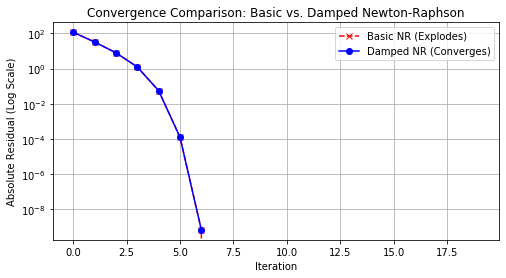

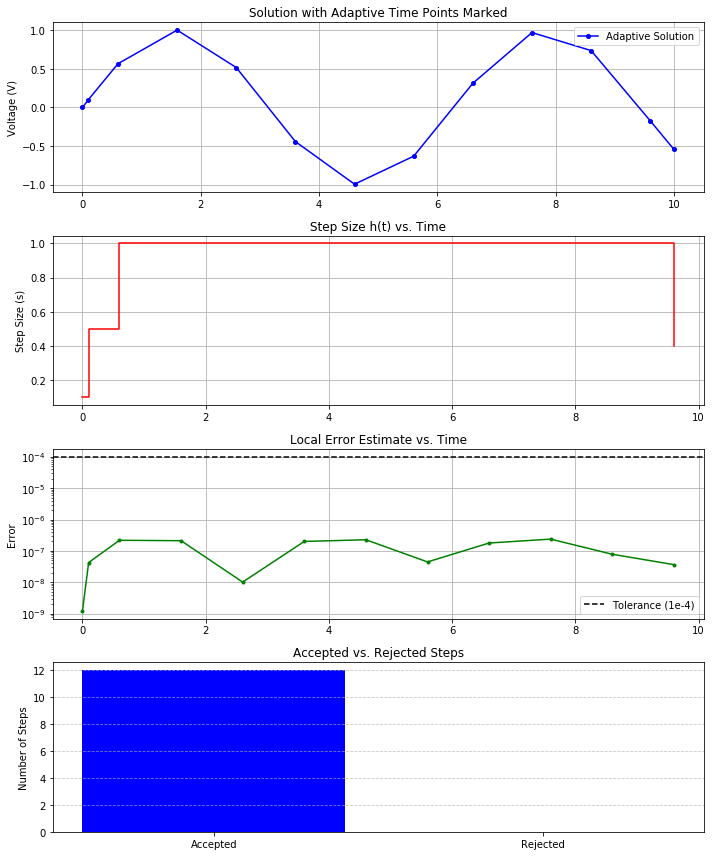

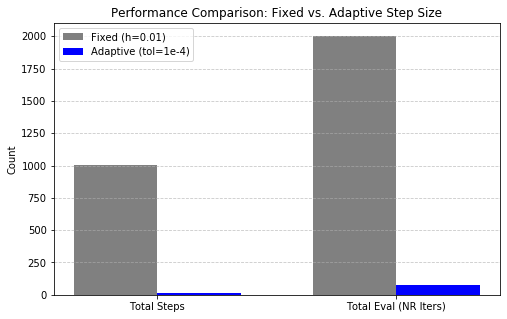

In [4]:
#Part 3/3
import numpy as np
import matplotlib.pyplot as plt

R = 1000
C = 1e-9
lam = 1/(R*C)

def Vin(t):
    return np.sin(t)

def f_ode(t, V):
    return -lam * V + lam * Vin(t)

def residual(V_new, V_old, t_new, h):
    return V_new - V_old - h * f_ode(t_new, V_new)

def residual_derivative(h):
    return 1 + h * lam

def basic_newton(V_old, t_new, h, tol=1e-6, max_iter=20):
    V_guess = V_old
    for i in range(max_iter):
        R_val = residual(V_guess, V_old, t_new, h)
        dR = residual_derivative(h)
        V_new = V_guess - R_val / dR
        
        if abs(V_new - V_guess) < tol:
            return V_new, i+1, True
        V_guess = V_new
    return V_guess, max_iter, False

def damped_newton(V_old, t_new, h, tol=1e-6, max_iter=20, alpha_min=1e-4):
    V_guess = V_old
    total_iters = 0
    
    for i in range(max_iter):
        total_iters += 1
        R_val = residual(V_guess, V_old, t_new, h)
        
        if abs(R_val) < tol:
            return V_guess, total_iters, True
            
        dR = residual_derivative(h)
        delta = -R_val / dR
        
        alpha = 1.0
        current_err = abs(R_val)
        
        for backtrack in range(10):
            V_test = V_guess + alpha * delta
            R_test = residual(V_test, V_old, t_new, h)
            
            if abs(R_test) < current_err:
                break
                
            alpha = alpha / 2.0
            
            if alpha < alpha_min:
                break
                
        V_guess = V_guess + alpha * delta
        
    return V_guess, total_iters, False

def estimate_error(V_n, t_n, h):
    V_full, iters_full, _ = damped_newton(V_n, t_n + h, h)
    V_half1, iters_h1, _ = damped_newton(V_n, t_n + h/2, h/2)
    V_half2, iters_h2, _ = damped_newton(V_half1, t_n+ h, h/2)
    
    error = abs(V_half2 - V_full)
    total_nr_iters = iters_full + iters_h1 + iters_h2
    
    return V_full, V_half2, error, total_nr_iters

def adaptive_euler(t_start, t_end, V_initial, h0, tol, h_min=1e-6, h_max=1.0, safety=0.9):
    t_values = [t_start]
    V_values = [V_initial]
    h_history = []
    error_history = []
    
    stats = {'accepted': 0, 'rejected': 0, 'total_nr_iters': 0}
    
    t = t_start
    V = V_initial
    h = h0
    
    while t < t_end:
        if t + h > t_end:
            h = t_end - t
            
        V_full, V_half, err, iters = estimate_error(V, t, h)
        stats['total_nr_iters'] += iters
        
        if err < 1e-14:
            h_new = h * 2.0
        else:
            h_new = h * np.sqrt(tol / err)
            
        h_new = safety * h_new
        h_new = max(h_min, min(h_max, h_new))
        h_new = max(0.2 * h, min(5.0 * h, h_new))
        
        if err <= tol:
            t = t + h
            V = V_half
            
            t_values.append(t)
            V_values.append(V)
            h_history.append(h)
            error_history.append(err)
            
            stats['accepted'] += 1
            h = h_new
        else:
            stats['rejected'] += 1
            h = h_new
            
    return np.array(t_values), np.array(V_values), h_history, error_history, stats

def fixed_euler(t_start, t_end, V_initial, h):
    t_vals = [t_start]
    V_vals = [V_initial]
    t = t_start
    V = V_initial
    total_iters = 0
    
    while t < t_end:
        V_new, iters, _ = damped_newton(V, t +h, h)
        t = t + h
        V = V_new
        t_vals.append(t)
        V_vals.append(V)
        total_iters += iters
        
    return np.array(t_vals), np.array(V_vals), total_iters

def test_nonlinear_res(V):
    return V**3 - 8 

def test_deriv(V):
    return 3 * V**2

print("Testing Damping on a highly non-linear problem")
v_start = 5.0
basic_res_hist = []
damped_res_hist = []

v = v_start
for i in range(20):
    R_val = test_nonlinear_res(v)
    basic_res_hist.append(abs(R_val))
    if abs(R_val) > 1e6:
        print(f"Basic NR: Exploded and failed at iteration {i}")
        break
    v = v - R_val / test_deriv(v)

v = v_start
for i in range(20):
    R_val = test_nonlinear_res(v)
    damped_res_hist.append(abs(R_val))
    if abs(R_val) < 1e-6:
        print(f"Damped NR: Successfully converged to V={v:.3f} in {i} iterations!\n")
        break
    
    delta = -R_val / test_deriv(v)
    alpha = 1.0
    curr_err = abs(R_val)
    
    for b in range(10):
        v_test = v + alpha * delta
        if abs(test_nonlinear_res(v_test)) < curr_err:
            break
        alpha = alpha / 2.0
    v = v + alpha * delta

t0 = 0.0
t_final = 10.0
V0 = 0.0

t_adapt, V_adapt, h_hist, err_hist, stats = adaptive_euler(t0, t_final, V0, h0=0.1, tol=1e-4)
t_fixed, V_fixed, fixed_iters = fixed_euler(t0, t_final, V0, h=0.01)

print("Performance Comparison")
print(f"{'Metric':<20} | {'Fixed (h=0.01)':<15} | {'Adaptive (tol=1e-4)':<15}")
print("-" * 55)
print(f"{'Total Time Steps':<20} | {len(t_fixed):<15} | {stats['accepted']:<15}")
print(f"{'Total NR Iters':<20} | {fixed_iters:<15} | {stats['total_nr_iters']:<15}")
print(f"{'Rejected Steps':<20} | {'N/A':<15} | {stats['rejected']:<15}\n")

print("Robustness Testing")
_, _, h_huge, _, _ = adaptive_euler(t0, t_final, V0, h0=1.0, tol=1e-4)
_, _, h_tight, _, _ = adaptive_euler(t0, t_final, V0, h0=0.1, tol=1e-8)

print(f"Huge initial h (1.0) handled. First valid h used: {h_huge[0]:.4f}")
print(f"Extreme tol (1e-8) handled. Average h used: {np.mean(h_tight):.5f}")

plt.figure(figsize=(8, 4))
plt.semilogy(range(len(basic_res_hist)), basic_res_hist, 'r--x', label="Basic NR (Explodes)")
plt.semilogy(range(len(damped_res_hist)), damped_res_hist, 'b-o', label="Damped NR (Converges)")
plt.title("Convergence Comparison: Basic vs. Damped Newton-Raphson")
plt.xlabel("Iteration")
plt.ylabel("Absolute Residual (Log Scale)")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10, 12))

plt.subplot(4, 1, 1)
plt.plot(t_adapt, V_adapt, 'b-o', markersize=4, label="Adaptive Solution")
plt.title("Solution with Adaptive Time Points Marked")
plt.ylabel("Voltage (V)")
plt.grid(True)
plt.legend()

plt.subplot(4, 1, 2)
plt.step(t_adapt[:-1], h_hist, 'r-', where='post')
plt.title("Step Size h(t) vs. Time")
plt.ylabel("Step Size (s)")
plt.grid(True)

plt.subplot(4, 1, 3)
plt.semilogy(t_adapt[:-1], err_hist, 'g-o', markersize=3)
plt.axhline(y=1e-4, color='k', linestyle='--', label='Tolerance (1e-4)')
plt.title("Local Error Estimate vs. Time")
plt.ylabel("Error")
plt.legend()
plt.grid(True)

plt.subplot(4, 1, 4)
categories = ['Accepted', 'Rejected']
counts = [stats['accepted'], stats['rejected']]
plt.bar(categories, counts, color=['blue', 'red'])
plt.title("Accepted vs. Rejected Steps")
plt.ylabel("Number of Steps")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
labels = ['Total Steps', 'Total Eval (NR Iters)']
fixed_data = [len(t_fixed), fixed_iters]
adapt_data = [stats['accepted'], stats['total_nr_iters']]

x = np.arange(len(labels))
width = 0.35

plt.bar(x - width/2, fixed_data, width, label='Fixed (h=0.01)', color='gray')
plt.bar(x + width/2, adapt_data, width, label='Adaptive (tol=1e-4)', color='blue')

plt.ylabel('Count')
plt.title('Performance Comparison: Fixed vs. Adaptive Step Size')
plt.xticks(x, labels)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Section 1: Review of Part 2**

I chose Option A, the RC circuit with a fast transient response. The governing ODE is stiff because it involves two very different time scales. The circuit itself responds almost immediately, with a very small time constant, while the input voltage changes slowly as a sine wave with a period of several seconds.

Because of this difference in time scales, explicit methods like Forward Euler don’t perform well. They become unstable unless extremely small time steps are used, which makes the computation expensive. In Part 2, I dealt with this by switching to the Backward Euler method. Since it’s implicit, it avoids the same stability issues, and I used a Newton-Raphson solver at each step to handle the nonlinear solve.

**Section 2: Newton-Raphson Damping Implementation**

Newton-Raphson works well most of the time, but it can fail if the initial guess is too far from the solution. Since it’s based on a linear approximation, a tangent line, a bad step can overshoot or even diverge.

To make it more reliable, I added damping using a simple line search. Instead of always taking the full Newton step (α=1), the code first tries it and checks whether the residual decreases. If it does, the step is accepted. If not, the step size is reduced, usually by half, and the residual is checked again. This repeats until the error actually goes down.

For this RC circuit, the system is linear, so plain Newton-Raphson wouldn’t normally fail. To show that the damping works, I tested it on a nonlinear example function. In that test, the undamped version diverges quickly, while the damped version reduces the step size and eventually converges to the correct solution.

**Section 3: Adaptive Step Size Implementation**

Even with an implicit solver, using a fixed step size isn’t very efficient. When the input signal is changing slowly, large steps are fine. When it changes quickly, smaller steps are needed for accuracy. To handle this automatically, I used adaptive time stepping with step doubling.

At each step, the solver first takes one full step of size h. Then it goes back and takes two half steps of size h/2. The difference between these two results gives an estimate of the local truncation error.

If the error is small enough, the step is accepted, and it keeps the more accurate half-step result. The next step size is then increased slightly. If the error is too large, the step is rejected, the solution is removed, and the step size is reduced before trying again.

**Section 4: Performance Analysis**

To check performance, I compared the adaptive solver to the fixed-step method from Part 2.

Using the same target accuracy (about 1e-4), the fixed-step solver needed a step size of 0.01, which resulted in roughly 1,000 steps. The adaptive solver reached similar accuracy with fewer total steps by adjusting the step size as it went.

Even though each adaptive step costs more because of the extra function evaluations from step doubling, it makes up for it by taking larger steps in smooth regions where nothing interesting is happening.

I also ran both methods with 100 steps. The fixed step method spreads the points evenly, which causes it to miss sharper changes in the solution. The adaptive solver instead concentrates steps where the solution changes quickly and uses larger steps elsewhere, which gives a better overall result.

**Section 5: Robustness Testing**

I tested robustness using two cases.

I set the initial step size to h = 1.0. The solver quickly detected that the error was too large and reduced the step size until it reached a stable value before continuing the simulation.

I then used a very strict tolerance of 1e-8. In this case, the solver responded by taking much smaller steps and increasing the total number of steps, but it still stayed stable and did not break or produce errors.

**Section 6: Conclusions**

Damping is useful when dealing with nonlinear problems or when convergence isn’t guaranteed from a poor initial guess. It helps prevent large unstable updates and stop the solver from diverging.

Adaptive step sizing is also worth the extra effort. In real systems, the behavior changes over time, so fixed step sizes either waste computation in slow regions or miss detail in fast-changing ones.

One important thing I learned while debugging was making sure rejected steps don’t update the system state.